## Attempt

I attempted to work with PCA to reduce dimensionality with my created features post-aggregation. These features are the general summary statistics for amount and include some date-related measures. After standard scaling variables, I implemented an XGBoost model with a base score of 0.5 and log loss function.

In addition, I created a function that compares the correlation between these variables and FPF_TARGET; I also calculate the mean of these variables by FPF_TARGET label.

## Main Findings

- PCA may not exactly be the right for this model; it reduced my baseline model accuracy down to 50%. This can be due to limited data, however. More testing will need to be done to determine whether or not I will continue to work with PCA.

- mean_pos_amount, range_date_posted, first_date_posted, max_amount, fin_balance, mean_date_posted have the highest correlation to FPF_TARGET. This can indicate that these variables are quite helpful in differentiating between the FPF_TARGET labels.

- There are noticeable differences in variables means between the two FPF_TARGET labels for the following variables: total_amount, fin_balance, total_pos_amount, mean_neg_amount, mean_amount, min_amount, max_amount, range_date_posted, date_mean_median_diff_posted. Again, this can indicate that these variables are quite helpful in differentiating between the FPF_TARGET labels.

- This baseline model achieves an accuracy on the sample data of ~60%--slightly better than guessing. My next steps are with optimization to improve the model to hopefully achieve the baseline accuracy of 90%....

In [3]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from abc import ABC, abstractmethod
from pathlib import Path

from cashflow import ScorableModelTemplate
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


import warnings
warnings.filterwarnings("ignore")

## Baseline Model

In [45]:
class ScorableModel(ScorableModelTemplate):

    def predict(self, raw_consumer_file: str, raw_transactions_file: str):
        """Input argument will vary. See you competition's template.

        :param raw_files: list of file path strings, depends on competition
        :return predictions: dataframe or np.array, depends on competition
        """
        # Process data
        df_consumers = self.process_inputs(raw_consumer_file, raw_transactions_file) 

        # Create variables for model
        def helper(group_df):
            result = {
                'num_transactions': group_df['amount'].count(),
                'total_amount': group_df['amount'].sum(),
                'fin_balance': group_df['total_balance'].mean(),
                'total_pos_amount': group_df[group_df['amount'] > 0]['amount'].sum(),
                'total_neg_amount': group_df[group_df['amount'] < 0]['amount'].sum(),
                'mean_pos_amount': group_df[group_df['amount'] > 0]['amount'].mean(),
                'mean_neg_amount': group_df[group_df['amount'] < 0]['amount'].mean(),
                'mean_amount': group_df['amount'].mean(),
                'amount_mean_median_diff': group_df['amount'].mean() - group_df['amount'].median(),
                'min_amount': group_df['amount'].min(),
                'max_amount': group_df['amount'].max(),
                'common_category': group_df['category'].mode()[0],
                'date': group_df['evaluation_date'].min().timestamp(),
                'first_date_posted': group_df['posted_date'].min().timestamp(),
                'last_date_posted': group_df['posted_date'].max().timestamp(),
                'range_date_posted': (group_df['posted_date'].max() - group_df['posted_date'].min()).days,
                'mode_day_posted': group_df['posted_day'].mode()[0],
                'mean_date_posted': group_df['posted_date'].mean().timestamp(),
                'date_mean_median_diff_posted': (group_df['posted_date'].mean() - group_df['posted_date'].median()).days,
                'loan_category': group_df['loan_category'].min(),
                'FPF_TARGET': group_df['FPF_TARGET'].mean()
            }
            if len(group_df[group_df['amount'] > 0]) == 0:
                result['total_pos_amount'] = 0
                result['mean_pos_amount'] = 0
            elif len(group_df[group_df['amount'] < 0]) == 0:
                result['total_neg_amount'] = 0
                result['mean_neg_amount'] = 0
            return pd.Series(result)
        
        # Pass training, validation, and testing data through helper to prepare it for model

        ##################################TRAINING DATA####################################
        df_train = self.process_inputs("~/private/DSC 190/mlc/consumers_test_data.parquet", "~/private/DSC 190/mlc/transactions_test_data.parquet") #load processed features
        
        aggregated_train_data = df_train.groupby('masked_consumer_id').apply(helper).reset_index()
        aggregated_train_encoded = pd.get_dummies(aggregated_train_data.drop(columns=['masked_consumer_id']), drop_first=True)

        # Separate target
        train_target = aggregated_train_encoded['FPF_TARGET']
        train_features = aggregated_train_encoded.drop(columns='FPF_TARGET')

        # Standardize
        scaler = StandardScaler()
        train_features_scaled = scaler.fit_transform(train_features)
        
        # Run PCA
        pca = PCA()
        train_pca_components = pca.fit_transform(train_features_scaled)
        cumulative_var = np.cumsum(pca.explained_variance_ratio_)
        n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
        
        # Filter Variables based on % of variance explained
        pca_train_df = pd.DataFrame(
            train_pca_components[:, :n_components_95],
            columns=[f'PC{i+1}' for i in range(n_components_95)]
        )
        ##################################TESTING DATA####################################
        aggregated_data = df_consumers.groupby('masked_consumer_id').apply(helper).reset_index()
        aggregated_encoded = pd.get_dummies(aggregated_data.drop(columns=['masked_consumer_id']), drop_first=True)
        
        target = aggregated_encoded['FPF_TARGET']
        features = aggregated_encoded.drop(columns='FPF_TARGET')

        features_scaled = scaler.transform(features)
        
        pca_components = pca.transform(features_scaled)
        pca_df = pd.DataFrame(
            pca_components[:, :n_components_95],
            columns=[f'PC{i+1}' for i in range(n_components_95)]
        )
        
        
        # Initialize XGBoost model
        model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss',base_score=0.5)
        model.fit(pca_train_df, train_target)

        # Make predicitons
        y_pred = model.predict(pca_df)
        print(f"Accuracy Test: {accuracy_score(target, y_pred):.2f}")

        return y_pred

    def process_inputs(self, raw_consumer_file: str, raw_transactions_file: str):
        """Input argument will vary. See you competition's template.

        :param raw_files: list of file path strings, depends on competition
        :return: anything needed for you model to make predictions, e.g. features or processed data
        """
        # Read in files
        df_consumer = pd.read_parquet(raw_consumer_file)
        df_transactions = pd.read_parquet(raw_transactions_file)

        # Merge and filter to get only valid data
        merged_df = df_transactions.merge(df_consumer, on = "masked_consumer_id")
        filtered_df = merged_df[merged_df["posted_date"]< merged_df["evaluation_date"]]

        # Clean evaluation_date and create evaluation_day for day of week of evaluation_date
        filtered_df['evaluation_date'] = pd.to_datetime(filtered_df['evaluation_date'])
        filtered_df['evaluation_day'] = filtered_df['evaluation_date'].dt.dayofweek

        # Clean posted_date and create posted_day for day of week of posted_date
        filtered_df['posted_date'] = pd.to_datetime(filtered_df['posted_date'])
        filtered_df['posted_day'] = filtered_df['posted_date'].dt.dayofweek

        # Get loan category from masked_consumer_id
        filtered_df['loan_category'] = filtered_df['masked_consumer_id'].str[2].astype(int)
        
        return filtered_df

# Create model <- initially run on basic test data
model = ScorableModel() 

Accuracy Test: 0.50


In [52]:
# Run model on sample data

_, true_output = model.load_test_case()
predictions = model.predict("~/private/DSC 190/mlc/consumers_test_data.parquet", "~/private/DSC 190/mlc/transactions_test_data.parquet")

Accuracy Validate: 0.72
Accuracy Test: 0.93


### Variable Correlations with FPF

In [21]:
## SAME CODE AS MODEL ABOVE

# Read in data
my_df = model.process_inputs("~/private/DSC 190/mlc/consumers_test_data.parquet", 
                             "~/private/DSC 190/mlc/transactions_test_data.parquet")
# Create features for model
def helper(group_df):
    result = {
        'num_transactions': group_df['amount'].count(),
        'total_amount': group_df['amount'].sum(),
        'fin_balance': group_df['total_balance'].mean(),
        'total_pos_amount': group_df[group_df['amount'] > 0]['amount'].sum(),
        'total_neg_amount': group_df[group_df['amount'] < 0]['amount'].sum(),
        'mean_pos_amount': group_df[group_df['amount'] > 0]['amount'].mean(),
        'mean_neg_amount': group_df[group_df['amount'] < 0]['amount'].mean(),
        'mean_amount': group_df['amount'].mean(),
        'amount_mean_median_diff': group_df['amount'].mean() - group_df['amount'].median(),
        'min_amount': group_df['amount'].min(),
        'max_amount': group_df['amount'].max(),
        'common_category': group_df['category'].mode()[0],
        'date': group_df['evaluation_date'].min().timestamp(),
        'first_date_posted': group_df['posted_date'].min().timestamp(),
        'last_date_posted': group_df['posted_date'].max().timestamp(),
        'range_date_posted': (group_df['posted_date'].max() - group_df['posted_date'].min()).days,
        'mode_day_posted': group_df['posted_day'].mode()[0],
        'mean_date_posted': group_df['posted_date'].mean().timestamp(),
        'date_mean_median_diff_posted': (group_df['posted_date'].mean() - group_df['posted_date'].median()).days,
        'loan_category': group_df['loan_category'].min(),
        'FPF_TARGET': group_df['FPF_TARGET'].mean()
    }
    if len(group_df[group_df['amount'] > 0]) == 0:
        result['total_pos_amount'] = 0
        result['mean_pos_amount'] = 0
    elif len(group_df[group_df['amount'] < 0]) == 0:
        result['total_neg_amount'] = 0
        result['mean_neg_amount'] = 0
    return pd.Series(result)

# Prepare data for model
aggregated_data = my_df.groupby('masked_consumer_id').apply(helper).reset_index()
aggregated_encoded = pd.get_dummies(aggregated_data.drop(columns=['masked_consumer_id']), drop_first=True)

# Separate data between features and target 
target = aggregated_encoded['FPF_TARGET']
features = aggregated_encoded.drop(columns='FPF_TARGET')

# Standardize
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)


# Correlation function to find features correlation with FPF_TARGET
def correlation_with_x(df, x="FPF_TARGET"):
    if x not in df.columns:
        raise ValueError(f"{x} is not a column in the DataFrame")
    numeric_df = df.select_dtypes(include='number')
    correlation_row = numeric_df.corr().loc[x].drop(x)
    return correlation_row.to_frame(name=f'correlation_with_{x}').T

# Find correlations
correlation_result = correlation_with_x(aggregated_encoded)
print(correlation_result)

                             num_transactions  total_amount  fin_balance  \
correlation_with_FPF_TARGET          0.037665       0.03886    -0.209119   

                             total_pos_amount  total_neg_amount  \
correlation_with_FPF_TARGET         -0.197923          0.185542   

                             mean_pos_amount  mean_neg_amount  mean_amount  \
correlation_with_FPF_TARGET        -0.288391         0.161204     0.101912   

                             amount_mean_median_diff  min_amount  max_amount  \
correlation_with_FPF_TARGET                 0.015118     0.18759   -0.204316   

                             common_category      date  first_date_posted  \
correlation_with_FPF_TARGET        -0.101483  0.136436           0.288586   

                             last_date_posted  range_date_posted  \
correlation_with_FPF_TARGET          0.166606          -0.294773   

                             mode_day_posted  mean_date_posted  \
correlation_with_FPF_TARGET         

**Variables of interest: fin_balance, mean_pos_amount, first_date_posted, max_amount, range_date_posted, mean_date_posted**

### PCA Analysis

In [23]:
# Read in data

my_df = model.process_inputs("~/private/DSC 190/mlc/consumers_test_data.parquet", 
                             "~/private/DSC 190/mlc/transactions_test_data.parquet")

# Create features for model
def helper(group_df):
    result = {
        'num_transactions': group_df['amount'].count(),
        'total_amount': group_df['amount'].sum(),
        'fin_balance': group_df['total_balance'].mean(),
        'total_pos_amount': group_df[group_df['amount'] > 0]['amount'].sum(),
        'total_neg_amount': group_df[group_df['amount'] < 0]['amount'].sum(),
        'mean_pos_amount': group_df[group_df['amount'] > 0]['amount'].mean(),
        'mean_neg_amount': group_df[group_df['amount'] < 0]['amount'].mean(),
        'mean_amount': group_df['amount'].mean(),
        'amount_mean_median_diff': group_df['amount'].mean() - group_df['amount'].median(),
        'min_amount': group_df['amount'].min(),
        'max_amount': group_df['amount'].max(),
        'common_category': group_df['category'].mode()[0],
        'date': group_df['evaluation_date'].min().timestamp(),
        'first_date_posted': group_df['posted_date'].min().timestamp(),
        'last_date_posted': group_df['posted_date'].max().timestamp(),
        'range_date_posted': (group_df['posted_date'].max() - group_df['posted_date'].min()).days,
        'mode_day_posted': group_df['posted_day'].mode()[0],
        'mean_date_posted': group_df['posted_date'].mean().timestamp(),
        'date_mean_median_diff_posted': (group_df['posted_date'].mean() - group_df['posted_date'].median()).days,
        'loan_category': group_df['loan_category'].min(),
        'FPF_TARGET': group_df['FPF_TARGET'].mean()
    }
    if len(group_df[group_df['amount'] > 0]) == 0:
        result['total_pos_amount'] = 0
        result['mean_pos_amount'] = 0
    elif len(group_df[group_df['amount'] < 0]) == 0:
        result['total_neg_amount'] = 0
        result['mean_neg_amount'] = 0
    return pd.Series(result)

# Aggregate dataset for the model
aggregated_data = my_df.groupby('masked_consumer_id').apply(helper).reset_index()

# one-hot-encode categorical variables
aggregated_encoded = pd.get_dummies(aggregated_data.drop(columns=['masked_consumer_id']), drop_first=True)

# Separate target and features
target = aggregated_encoded['FPF_TARGET']
features = aggregated_encoded.drop(columns='FPF_TARGET')

# Standardize
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Run PCA
pca = PCA()
pca_components = pca.fit_transform(features_scaled)

# Create a DataFrame with principal components
pca_df = pd.DataFrame(pca_components, columns=[f'PC{i+1}' for i in range(pca_components.shape[1])])
pca_df['FPF_TARGET'] = target.values

# Run correlation
correlation_result = correlation_with_x(pca_df)
print(correlation_result)

                                 PC1       PC2       PC3       PC4       PC5  \
correlation_with_FPF_TARGET -0.22747 -0.171389 -0.050643  0.003181  0.165882   

                                  PC6       PC7       PC8       PC9      PC10  \
correlation_with_FPF_TARGET  0.031518  0.099207 -0.109583  0.293035 -0.057378   

                                 PC11      PC12      PC13      PC14      PC15  \
correlation_with_FPF_TARGET -0.017922 -0.164133  0.059065 -0.119333 -0.153594   

                                 PC16      PC17      PC18      PC19      PC20  
correlation_with_FPF_TARGET  0.000922 -0.057115 -0.108013 -0.051943 -0.127438  


**Variables of interest: PC1, PC2, PC5, PC9 (suprising), PC14 (suprising), PC15 (suprising), PC20 (suprising)**

## Test different values of n_components percentage 

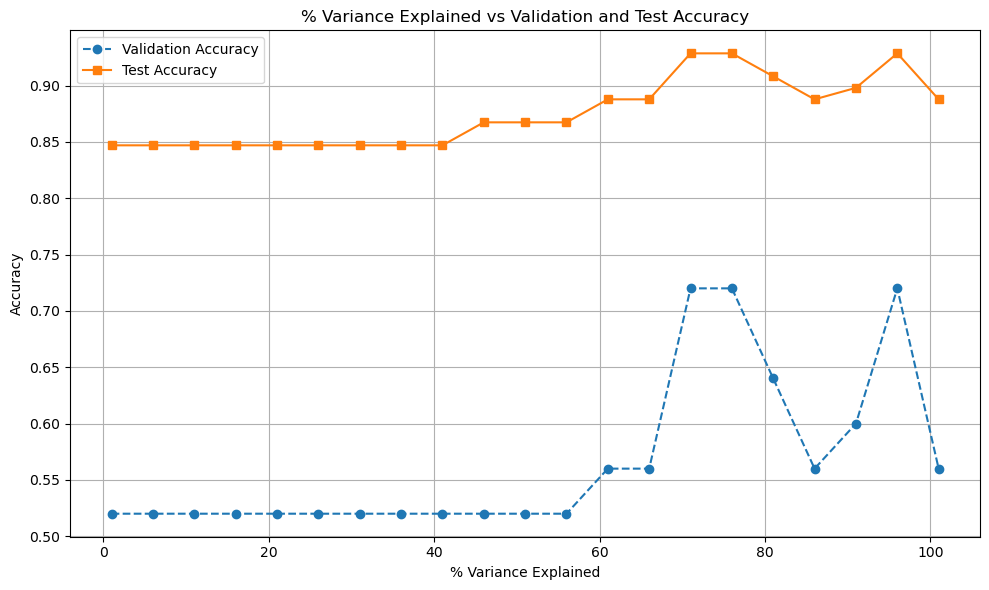

In [50]:
def predict_test(raw_consumer_file: str, raw_transactions_file: str, n_component_val: int):
    """Input argument will vary. See you competition's template.

    :param raw_files: list of file path strings, depends on competition
    :return predictions: dataframe or np.array, depends on competition
    """
    # Preprocess data
    df_consumers = process_inputs_test(raw_consumer_file, raw_transactions_file)

    # Prepare features for model using helper function
    def helper(group_df):
        result = {
            'num_transactions': group_df['amount'].count(),
            'total_amount': group_df['amount'].sum(),
            'fin_balance': group_df['total_balance'].mean(),
            'total_pos_amount': group_df[group_df['amount'] > 0]['amount'].sum(),
            'total_neg_amount': group_df[group_df['amount'] < 0]['amount'].sum(),
            'mean_pos_amount': group_df[group_df['amount'] > 0]['amount'].mean(),
            'mean_neg_amount': group_df[group_df['amount'] < 0]['amount'].mean(),
            'mean_amount': group_df['amount'].mean(),
            'amount_mean_median_diff': group_df['amount'].mean() - group_df['amount'].median(),
            'min_amount': group_df['amount'].min(),
            'max_amount': group_df['amount'].max(),
            'common_category': group_df['category'].mode()[0],
            'date': group_df['evaluation_date'].min().timestamp(),
            'first_date_posted': group_df['posted_date'].min().timestamp(),
            'last_date_posted': group_df['posted_date'].max().timestamp(),
            'range_date_posted': (group_df['posted_date'].max() - group_df['posted_date'].min()).days,
            'mode_day_posted': group_df['posted_day'].mode()[0],
            'mean_date_posted': group_df['posted_date'].mean().timestamp(),
            'date_mean_median_diff_posted': (group_df['posted_date'].mean() - group_df['posted_date'].median()).days,
            'loan_category': group_df['loan_category'].min(),
            'FPF_TARGET': group_df['FPF_TARGET'].mean()
        }
        if len(group_df[group_df['amount'] > 0]) == 0:
            result['total_pos_amount'] = 0
            result['mean_pos_amount'] = 0
        elif len(group_df[group_df['amount'] < 0]) == 0:
            result['total_neg_amount'] = 0
            result['mean_neg_amount'] = 0
        return pd.Series(result)
    
    # Aggregate data and pass through helper function

    ##################################TRAINING DATA####################################
    df_train = process_inputs_test("~/private/DSC 190/mlc/consumers_test_data.parquet", "~/private/DSC 190/mlc/transactions_test_data.parquet") #load processed features
    
    aggregated_train_data = df_train.groupby('masked_consumer_id').apply(helper).reset_index()
    aggregated_train_encoded = pd.get_dummies(aggregated_train_data.drop(columns=['masked_consumer_id']), drop_first=True)

    # Separate target and features for training data
    train_target = aggregated_train_encoded['FPF_TARGET']
    train_features = aggregated_train_encoded.drop(columns='FPF_TARGET')

    # Train, validate split
    X_train, X_test, y_train, y_test = train_test_split(train_features, train_target, test_size=0.25, random_state=42)
    
    # Standardize X_train
    scaler = StandardScaler()
    train_features_scaled = scaler.fit_transform(X_train)
    
    # X_train PCA
    pca = PCA()
    train_pca_components = pca.fit_transform(train_features_scaled)
    cumulative_var = np.cumsum(pca.explained_variance_ratio_)

    # Get PCA variables that explain up to n_component_val variance
    n_components_95 = np.argmax(cumulative_var >= n_component_val) + 1
    
    # Create DataFrame with only the most significant components
    pca_train_df = pd.DataFrame(
        train_pca_components[:, :n_components_95],
        columns=[f'PC{i+1}' for i in range(n_components_95)]
    )

    ###VALIDATE####
    # Preform same preparations as before
    validate_features_scaled = scaler.transform(X_test)
    
    curr_pca_components = pca.transform(validate_features_scaled)
    validate_pca_df = pd.DataFrame(
        curr_pca_components[:, :n_components_95],
        columns=[f'PC{i+1}' for i in range(n_components_95)]
    )
    
    ##################################TESTING DATA####################################
    # Preform same preparations as before on testing data
    aggregated_data = df_consumers.groupby('masked_consumer_id').apply(helper).reset_index()
    aggregated_encoded = pd.get_dummies(aggregated_data.drop(columns=['masked_consumer_id']), drop_first=True)
    
    target = aggregated_encoded['FPF_TARGET']
    features = aggregated_encoded.drop(columns='FPF_TARGET')

    features_scaled = scaler.transform(features)
    
    pca_components = pca.transform(features_scaled)
    pca_df = pd.DataFrame(
        pca_components[:, :n_components_95],
        columns=[f'PC{i+1}' for i in range(n_components_95)]
    )
    
        
    # Initialize XGBoost model
    model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss',base_score=0.5)
    model.fit(pca_train_df, y_train)

    # Run model on validation data to get predicitons
    y_validate = model.predict(validate_pca_df)
    #print(f"Accuracy Validate: {accuracy_score(y_test, y_validate):.2f}")

    # Run model on testing data to get predicitons
    y_pred = model.predict(pca_df)
    #print(f"Accuracy Test: {accuracy_score(target, y_pred):.2f}")

    return accuracy_score(y_test, y_validate), accuracy_score(target, y_pred)

def process_inputs(self, raw_consumer_file: str, raw_transactions_file: str):
    """Input argument will vary. See you competition's template.

    :param raw_files: list of file path strings, depends on competition
    :return: anything needed for you model to make predictions, e.g. features or processed data
    """
    # Read in files
    df_consumer = pd.read_parquet(raw_consumer_file)
    df_transactions = pd.read_parquet(raw_transactions_file)

    # Merge and filter to get only valid data
    merged_df = df_transactions.merge(df_consumer, on = "masked_consumer_id")
    filtered_df = merged_df[merged_df["posted_date"]< merged_df["evaluation_date"]]

    # Clean evaluation_date and create evaluation_day for day of week of evaluation_date
    filtered_df['evaluation_date'] = pd.to_datetime(filtered_df['evaluation_date'])
    filtered_df['evaluation_day'] = filtered_df['evaluation_date'].dt.dayofweek

    # Clean posted_date and create posted_day for day of week of posted_date
    filtered_df['posted_date'] = pd.to_datetime(filtered_df['posted_date'])
    filtered_df['posted_day'] = filtered_df['posted_date'].dt.dayofweek

    # Get loan category from masked_consumer_id
    filtered_df['loan_category'] = filtered_df['masked_consumer_id'].str[2].astype(int)
    
    return filtered_df

# Test % variance from .01 to 1
component_range = range(1, 106, 5)  
validation_scores = []  
test_scores = []  

for i in component_range:
    if i / 100 >= 1:
        curr_val, curr_test = predict_test("~/private/DSC 190/mlc/consumers_test_data.parquet", "~/private/DSC 190/mlc/transactions_test_data.parquet", 1)
    else:
        curr_val, curr_test = predict_test("~/private/DSC 190/mlc/consumers_test_data.parquet", "~/private/DSC 190/mlc/transactions_test_data.parquet", i / 100)
    validation_scores.append(curr_val)
    test_scores.append(curr_test)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(component_range, validation_scores, label='Validation Accuracy', marker='o', linestyle='--')
plt.plot(component_range, test_scores, label='Test Accuracy', marker='s', linestyle='-')

plt.title('% Variance Explained vs Validation and Test Accuracy')
plt.xlabel('% Variance Explained')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Test accuracy high (as includes results of model on train and validation data); need to specifically focus on validation accuracy.

Proportions to further explore: .65 < x <= .8, .9 <= x < 1

## Model Implementation

In [54]:
class ScorableModel(ScorableModelTemplate):   
    def predict(self, raw_consumer_file: str, raw_transactions_file: str):
        """Input argument will vary. See you competition's template.
    
        :param raw_files: list of file path strings, depends on competition
        :return predictions: dataframe or np.array, depends on competition
        """
        # Preprocess data
        df_consumers = self.process_inputs(raw_consumer_file, raw_transactions_file)

        # Helper function to create features for model
        def helper(group_df):
            result = {
                'num_transactions': group_df['amount'].count(),
                'total_amount': group_df['amount'].sum(),
                'fin_balance': group_df['total_balance'].mean(),
                'total_pos_amount': group_df[group_df['amount'] > 0]['amount'].sum(),
                'total_neg_amount': group_df[group_df['amount'] < 0]['amount'].sum(),
                'mean_pos_amount': group_df[group_df['amount'] > 0]['amount'].mean(),
                'mean_neg_amount': group_df[group_df['amount'] < 0]['amount'].mean(),
                'mean_amount': group_df['amount'].mean(),
                'amount_mean_median_diff': group_df['amount'].mean() - group_df['amount'].median(),
                'min_amount': group_df['amount'].min(),
                'max_amount': group_df['amount'].max(),
                'common_category': group_df['category'].mode()[0],
                'date': group_df['evaluation_date'].min().timestamp(),
                'first_date_posted': group_df['posted_date'].min().timestamp(),
                'last_date_posted': group_df['posted_date'].max().timestamp(),
                'range_date_posted': (group_df['posted_date'].max() - group_df['posted_date'].min()).days,
                'mode_day_posted': group_df['posted_day'].mode()[0],
                'mean_date_posted': group_df['posted_date'].mean().timestamp(),
                'date_mean_median_diff_posted': (group_df['posted_date'].mean() - group_df['posted_date'].median()).days,
                'loan_category': group_df['loan_category'].min(),
                'FPF_TARGET': group_df['FPF_TARGET'].mean()
            }
            if len(group_df[group_df['amount'] > 0]) == 0:
                result['total_pos_amount'] = 0
                result['mean_pos_amount'] = 0
            elif len(group_df[group_df['amount'] < 0]) == 0:
                result['total_neg_amount'] = 0
                result['mean_neg_amount'] = 0
            return pd.Series(result)
        
        # Aggregate data and pass through helper so that it is ready for the model
        ##################################TRAINING DATA####################################
        df_train = self.process_inputs("~/private/DSC 190/mlc/consumers_test_data.parquet", "~/private/DSC 190/mlc/transactions_test_data.parquet") #load processed features
        
        aggregated_train_data = df_train.groupby('masked_consumer_id').apply(helper).reset_index()
        aggregated_train_encoded = pd.get_dummies(aggregated_train_data.drop(columns=['masked_consumer_id']), drop_first=True)
    
        # Separate target
        train_target = aggregated_train_encoded['FPF_TARGET']
        train_features = aggregated_train_encoded.drop(columns='FPF_TARGET')

        # Separate train, validate data
        X_train, X_test, y_train, y_test = train_test_split(train_features, train_target, test_size=0.25, random_state=42)
        
        # Standardize
        scaler = StandardScaler()
        train_features_scaled = scaler.fit_transform(X_train)
        
        # PCA
        pca = PCA()
        train_pca_components = pca.fit_transform(train_features_scaled)
        cumulative_var = np.cumsum(pca.explained_variance_ratio_)

        # 70% variance explained
        num_components = np.argmax(cumulative_var >= 0.7) + 1
        
        # Create DataFrame with only the most significant components
        pca_train_df = pd.DataFrame(
            train_pca_components[:, :num_components],
            columns=[f'PC{i+1}' for i in range(num_components)]
        )
        ###VALIDATE####
        # Run same transformations
        validate_features_scaled = scaler.transform(X_test)
        
        curr_pca_components = pca.transform(validate_features_scaled)
        validate_pca_df = pd.DataFrame(
            curr_pca_components[:, :num_components],
            columns=[f'PC{i+1}' for i in range(num_components)]
        )
        
        ##################################TESTING DATA####################################
        # Run same transformations
        aggregated_data = df_consumers.groupby('masked_consumer_id').apply(helper).reset_index()
        aggregated_encoded = pd.get_dummies(aggregated_data.drop(columns=['masked_consumer_id']), drop_first=True)
        
        target = aggregated_encoded['FPF_TARGET']
        features = aggregated_encoded.drop(columns='FPF_TARGET')
    
        features_scaled = scaler.transform(features)
        
        pca_components = pca.transform(features_scaled)
        pca_df = pd.DataFrame(
            pca_components[:, :num_components],
            columns=[f'PC{i+1}' for i in range(num_components)]
        )
        
            
        # Initialize XGBoost model
        model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss',base_score=0.5)
        model.fit(pca_train_df, y_train)

        # Run model on validation data to make predictions
        y_validate = model.predict(validate_pca_df)
        print(f"Accuracy Validate: {accuracy_score(y_test, y_validate):.2f}")
    
        # Run model on testing data to make predictions
        y_pred = model.predict(pca_df)
        print(f"Accuracy Test: {accuracy_score(target, y_pred):.2f}")
    
        return y_pred
    
    def process_inputs(self, raw_consumer_file: str, raw_transactions_file: str):
        """Input argument will vary. See you competition's template.
    
        :param raw_files: list of file path strings, depends on competition
        :return: anything needed for you model to make predictions, e.g. features or processed data
        """
        # Read in files
        df_consumer = pd.read_parquet(raw_consumer_file)
        df_transactions = pd.read_parquet(raw_transactions_file)
    
        # Merge and filter to get only valid data
        merged_df = df_transactions.merge(df_consumer, on = "masked_consumer_id")
        filtered_df = merged_df[merged_df["posted_date"]< merged_df["evaluation_date"]]
    
        # Clean evaluation_date and create evaluation_day for day of week of evaluation_date
        filtered_df['evaluation_date'] = pd.to_datetime(filtered_df['evaluation_date'])
        filtered_df['evaluation_day'] = filtered_df['evaluation_date'].dt.dayofweek
    
        # Clean posted_date and create posted_day for day of week of posted_date
        filtered_df['posted_date'] = pd.to_datetime(filtered_df['posted_date'])
        filtered_df['posted_day'] = filtered_df['posted_date'].dt.dayofweek
    
        # Get loan category from masked_consumer_id
        filtered_df['loan_category'] = filtered_df['masked_consumer_id'].str[2].astype(int)
        
        return filtered_df

model = ScorableModel()

model.predict("~/private/DSC 190/mlc/consumers_test_data.parquet", "~/private/DSC 190/mlc/transactions_test_data.parquet")

Accuracy Validate: 0.72
Accuracy Test: 0.50
Accuracy Validate: 0.72
Accuracy Test: 0.93


array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0])